# Cyclistic Bike Sharing — Analisi delle Differenze tra Member e Casual

**Obiettivo:** Capire come si comportano i rider casual vs abbonati (member)
per supportare strategie di marketing mirate alla conversione.

**Dataset:** ~5.8 milioni di corse | Periodo: Giugno 2025 – Maggio 2026
  
**Strumenti:** Python, Pandas, Matplotlib, Seaborn

In [1]:
#importo la libreria pandas per la manipolazione dei dati
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px


In [2]:
#carico singolarmente i file csv dei 12 mesi e li unisco in un unico dataframe chiamato "anno" per poter lavorare su tutti i dati insieme
rides_month1 = pd.read_csv('202506-divvy-tripdata.csv')
rides_month2 = pd.read_csv('202507-divvy-tripdata.csv')
rides_month3 = pd.read_csv('202508-divvy-tripdata.csv')
rides_month4 = pd.read_csv('202509-divvy-tripdata.csv')
rides_month5 = pd.read_csv('202510-divvy-tripdata.csv')
rides_month6 = pd.read_csv('202511-divvy-tripdata.csv')
rides_month7 = pd.read_csv('202512-divvy-tripdata.csv')
rides_month8 = pd.read_csv('202601-divvy-tripdata.csv')
rides_month9 = pd.read_csv('202602-divvy-tripdata.csv')
rides_month10 = pd.read_csv('202603-divvy-tripdata.csv')
rides_month11 = pd.read_csv('202604-divvy-tripdata.csv')
rides_month12 = pd.read_csv('202605-divvy-tripdata.csv')
#unisco i 12 mesi in un unico dataframe chiamato "ride_year" e resetto l'indice per avere un indice continuo da 0 a n-1, dove n è il numero totale di righe del nuovo dataframe
ride_year = pd.concat([rides_month1, rides_month2, rides_month3, rides_month4, rides_month5, rides_month6, rides_month7, rides_month8, rides_month9, rides_month10, rides_month11, rides_month12], ignore_index=True)

In [3]:
 #controllo il numero di righe e colonne, i tipi di dati
ride_year.info()

<class 'pandas.DataFrame'>
RangeIndex: 5848703 entries, 0 to 5848702
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 580.1 MB


In [4]:
#approfondisco la ricerca di valori nulli 
ride_year.isnull().sum() 

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1249667
start_station_id      1249667
end_station_name      1314334
end_station_id        1314334
start_lat                   0
start_lng                   0
end_lat                  5896
end_lng                  5896
member_casual               0
dtype: int64

In [5]:
#creo un nuovo dataframe per facilitare la visualizzazione dei dati eliminando tutte colonne con i valori nulli che non devo utilizzare
ride_clean = ride_year[['ride_id','rideable_type', 'started_at', 'ended_at', 'member_casual' ]]
ride_clean.head(10)

,ride_id,rideable_type,started_at,ended_at,member_casual
0,0E43949BF937C7DA,electric_bike,2025-06-05 21:24:56.104,2025-06-05 21:38:44.446,member
1,1CDEA40FEAF21789,classic_bike,2025-06-14 13:03:34.478,2025-06-14 13:13:19.791,member
2,7ECEB1638575575C,classic_bike,2025-06-09 13:30:22.540,2025-06-09 13:39:53.640,member
3,F275084E25F5A131,electric_bike,2025-06-15 12:48:13.321,2025-06-15 13:00:18.798,member
4,F42E81C85AC722FB,electric_bike,2025-06-19 07:54:26.103,2025-06-19 08:04:36.583,member
5,6EEC90FDF82096A9,electric_bike,2025-06-17 19:06:40.626,2025-06-17 19:19:26.412,member
6,26E86CA213DF47DD,classic_bike,2025-06-16 14:31:16.892,2025-06-16 14:34:14.641,member
7,8862F2F1B6224109,electric_bike,2025-06-18 23:25:12.745,2025-06-18 23:51:53.896,member
8,CA21D68E6F04E0DE,electric_bike,2025-06-06 16:53:06.560,2025-06-06 17:09:19.530,casual
9,A7BEA2FE9708F666,electric_bike,2025-06-05 21:38:57.402,2025-06-05 21:42:43.545,casual


In [6]:
#pulisco i dati dai duplicati che potrebbero essere presenti dopo l'unione dei 12 mesi o nei singoli mesi

#stampo il numero di righe del dataframe "ride_clean" prima di rimuovere i duplicati
print(f"Prima: {len(ride_clean)} righe")
#rimuovo eventuali righe duplicate
ride_clean = ride_clean.drop_duplicates() 
#stampo il numero di righe del dataframe "ride_clean" dopo la rimozione dei duplicati
print(f"Dopo: {len(ride_clean)} righe") 
#calcolo il numero di righe eliminate 
righe_eliminate = len(ride_year) - len(ride_clean) 
print(f"Righe eliminate: {righe_eliminate}")

Prima: 5848703 righe
Dopo: 5848668 righe
Righe eliminate: 35


In [7]:
#creo una colonna con la durata della corsa ride_length (creo una seconda colonna per facilitarne la visualizzazione ride_length_formatted)

#converto la colonna "started_at" in formato datetime per poter effettuare operazioni di data e ora
ride_clean['started_at'] = pd.to_datetime(ride_clean['started_at']) 
#converto la colonna "ended_at" in formato datetime per poter effettuare operazioni di data e ora
ride_clean['ended_at'] = pd.to_datetime(ride_clean['ended_at']) 
#calcolo la durata di ogni corsa in ore sottraendo la colonna "started_at" da "ended_at"
ride_clean['ride_length'] = (ride_clean['ended_at'] - ride_clean['started_at']) 
#creo una funzione per formattare la colonna "ride_length" in un formato più leggibile (hh:mm:ss)
def format_timedelta_cumulative(td):
    total_seconds = int(td.total_seconds())
    hours, remainder = divmod(abs(total_seconds), 3600)
    minutes, seconds = divmod(remainder, 60)
    sign = "-" if total_seconds < 0 else ""
    return f"{sign}{hours:02d}:{minutes:02d}:{seconds:02d}"
#applico la funzione di formattazione alla colonna "ride_length" e creo una nuova colonna "ride_length_formatted"
ride_clean['ride_length_formatted'] = ride_clean['ride_length'].apply(format_timedelta_cumulative)
#visualizzo le 10 corse più brevi
ride_clean.sort_values('ride_length').head(10)

,ride_id,rideable_type,started_at,ended_at,member_casual,ride_length,ride_length_formatted
3834331,5740B9AA6176D32C,classic_bike,2025-11-02 01:59:56.801,2025-11-02 01:05:09.113,member,-1 days +23:05:12.312000,-00:54:47
3804972,ED8C9D500F271C3D,classic_bike,2025-11-02 01:57:24.553,2025-11-02 01:02:44.165,member,-1 days +23:05:19.612000,-00:54:40
3751960,222A5E8650C55311,electric_bike,2025-11-02 01:55:51.266,2025-11-02 01:01:50.026,member,-1 days +23:05:58.760000,-00:54:01
3720834,985A3462DAACFFCF,classic_bike,2025-11-02 01:59:07.835,2025-11-02 01:05:19.214,member,-1 days +23:06:11.379000,-00:53:48
3936262,E37AEB3E9CE2343E,electric_bike,2025-11-02 01:56:26.465,2025-11-02 01:03:08.183,member,-1 days +23:06:41.718000,-00:53:18
3689823,4A659F1BB40EDBF7,electric_bike,2025-11-02 01:55:38.177,2025-11-02 01:04:35.315,casual,-1 days +23:08:57.138000,-00:51:02
3740757,434E3D11ABA96891,electric_bike,2025-11-02 01:59:40.156,2025-11-02 01:08:51.303,casual,-1 days +23:09:11.147000,-00:50:48
3806330,4976DE4C5F1AA516,electric_bike,2025-11-02 01:56:44.152,2025-11-02 01:06:51.164,member,-1 days +23:10:07.012000,-00:49:52
3760728,83995E751A0DB5D5,electric_bike,2025-11-02 01:50:50.530,2025-11-02 01:01:15.026,member,-1 days +23:10:24.496000,-00:49:35
3857147,093B3FC8E465DA4A,electric_bike,2025-11-02 01:52:58.523,2025-11-02 01:04:31.464,member,-1 days +23:11:32.941000,-00:48:27


In [8]:
#dopo aver riscontrato valori negativi nella colonna "ride_length", controllo quando sono i valori negativi o pari a zero
ride_clean.value_counts(ride_clean['ride_length'] <= pd.Timedelta(0))

ride_length
False    5848639
True          29
Name: count, dtype: int64

In [9]:
#avendo trovato solo 29 corse con durata pari a zero, decido di eliminarle dal dataframe 
#creo una maschera booleana per identificare le righe del dataframe "ride_clean" in cui la colonna "ride_length" è pari a zero o negativa
invalid_ride_lengths = ride_clean['ride_length'] <= pd.Timedelta(0) 
#filtro il dataframe per mantenere solo le righe in cui la colonna "ride_length" è maggiore di zero
ride_clean = ride_clean[~invalid_ride_lengths] 
#verifico che non ci siano più corse con durata pari a zero o negativa dopo la rimozione, confermando che i dati sono stati puliti correttamente
ride_clean.value_counts(ride_clean['ride_length'] <= pd.Timedelta(0)) 

ride_length
False    5848639
Name: count, dtype: int64

In [10]:
#conto il numero di corse con durata inferiore o uguale a 10 secondi per identificare eventuali errori nei dati
ride_clean.value_counts((ride_clean['ride_length'] <= pd.Timedelta(seconds=10)) | (ride_clean['ride_length'] > pd.Timedelta(hours=3))) 
#avendo trovato tante corse con durata inferiore o uguale a 10 secondi, segno questo dato e lo porto nell'analisi dei dati

ride_length
False    5794379
True       54260
Name: count, dtype: int64

In [11]:
#calcolo la percentuale di corse con durata inferiore o uguale a 10 secondi rispetto al totale delle corse
ride_short = f"{(ride_clean['ride_length'] <= pd.Timedelta(seconds=10)).mean() * 100:.2f}%"
print(f"Percentuale di corse con durata inferiore o uguale a 10 secondi: {ride_short} ")

Percentuale di corse con durata inferiore o uguale a 10 secondi: 0.64% 


In [12]:
#calcolo la percentuale di corse con durata superiore a 3 ore rispetto al totale delle corse
ride_long = f"{(ride_clean['ride_length'] > pd.Timedelta(hours=3)).mean() * 100:.2f}%"
print(f"Percentuale di corse con durata superiore a 3 ore: {ride_long}")

Percentuale di corse con durata superiore a 3 ore: 0.29%


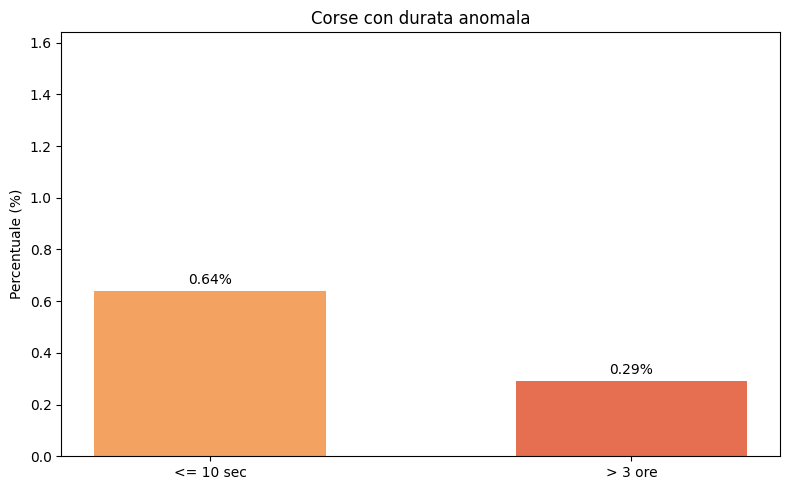

In [13]:
val_breve = float(ride_short.replace('%', ''))
val_lunga = float(ride_long.replace('%', ''))

etichette = ['<= 10 sec', '> 3 ore']
valori = [val_breve, val_lunga]
colori = ['#f4a261', '#e76f51']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(etichette, valori, color=colori, width=0.55)

ax.bar_label(bars, fmt='%.2f%%', padding=3)

ax.set_title('Corse con durata anomala')
ax.set_ylabel('Percentuale (%)')
ax.set_ylim(0, max(valori) + 1)

plt.tight_layout()
plt.show()

**L’analisi evidenzia una percentuale non trascurabile di corse estremamente brevi o molto lunghe. Questo può indicare la presenza di errori di registrazione, malfunzionamenti dell’applicazione o una scarsa chiarezza nella definizione delle fasi di inizio e fine della corsa.**

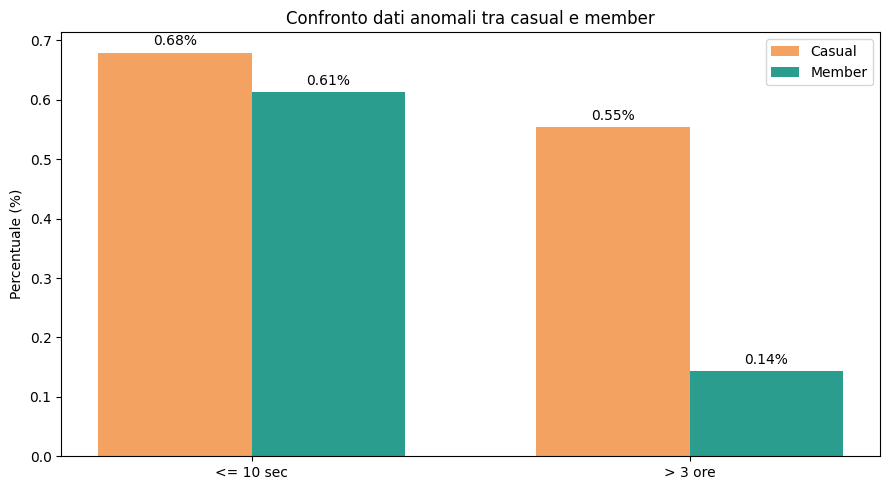

In [14]:
breve_casual = (ride_clean[ride_clean['member_casual'] == 'casual']['ride_length'] <= pd.Timedelta(seconds=10)).mean() * 100
lunga_casual = (ride_clean[ride_clean['member_casual'] == 'casual']['ride_length'] > pd.Timedelta(hours=3)).mean() * 100

breve_member = (ride_clean[ride_clean['member_casual'] == 'member']['ride_length'] <= pd.Timedelta(seconds=10)).mean() * 100
lunga_member = (ride_clean[ride_clean['member_casual'] == 'member']['ride_length'] > pd.Timedelta(hours=3)).mean() * 100

categorie = ['<= 10 sec', '> 3 ore']
casual = [breve_casual, lunga_casual]
member = [breve_member, lunga_member]

x = np.arange(len(categorie))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, casual, width, label='Casual', color='#f4a261')
bars2 = ax.bar(x + width/2, member, width, label='Member', color='#2a9d8f')

ax.bar_label(bars1, fmt='%.2f%%', padding=3)
ax.bar_label(bars2, fmt='%.2f%%', padding=3)

ax.set_title('Confronto dati anomali tra casual e member')
ax.set_ylabel('Percentuale (%)')
ax.set_xticks(x)
ax.set_xticklabels(categorie)
ax.legend()

plt.tight_layout()
plt.show()

**Si nota anche come molte dei problemi che ci sono sulle corse brevi le abbiamo anche per i membri che dovrebberò essere abituati a utilizzare l'applicazione, quindi bisognerebbe indagare su eventuali problemi dell'applicazione all'avvio della sessione di corsa**

**Decido quindi di eliminare questi valori perchè troppo alti o troppo bassi per non influenzare i valore del risultato finale**

In [15]:
#decido di eliminare i valori anomali (corse con durata inferiore a 10 secondi o superiore a 3 ore) per avere un'analisi più accurata dei dati
ride_filtered = ride_clean[
    (ride_clean['ride_length'] >= pd.Timedelta(seconds=10)) &
    (ride_clean['ride_length'] <= pd.Timedelta(hours=3))
]

In [16]:
#creo una nuova colonna "day_of_week" che rappresenta il giorno della settimana in cui è iniziata la corsa, utilizzando la funzione dt.dayofweek per estrarre il giorno della settimana dalla colonna "started_at" e applicando una formula per ottenere un formato da 1 a 7 (lunedi = 1, martedi = 2, ..., domenica = 7) per facilitare l'analisi dei dati in base ai giorni della settimana
ride_filtered['day_of_week'] = ride_filtered['started_at'].dt.dayofweek + 1
#creo una nuova colonna "month_num" che rappresenta il numero del mese in cui è iniziata la corsa
ride_filtered['month_num'] = ride_filtered['started_at'].dt.month 
ride_filtered['month'] = ride_filtered['started_at'].dt.month_name(locale='it_IT') #creo una nuova colonna "month" che rappresenta il nome del mese in cui è iniziata la corsa 
ride_filtered.head(10)

,ride_id,rideable_type,started_at,ended_at,member_casual,ride_length,ride_length_formatted,day_of_week,month_num,month
0,0E43949BF937C7DA,electric_bike,2025-06-05 21:24:56.104,2025-06-05 21:38:44.446,member,0 days 00:13:48.342000,00:13:48,4,6,Giugno
1,1CDEA40FEAF21789,classic_bike,2025-06-14 13:03:34.478,2025-06-14 13:13:19.791,member,0 days 00:09:45.313000,00:09:45,6,6,Giugno
2,7ECEB1638575575C,classic_bike,2025-06-09 13:30:22.540,2025-06-09 13:39:53.640,member,0 days 00:09:31.100000,00:09:31,1,6,Giugno
3,F275084E25F5A131,electric_bike,2025-06-15 12:48:13.321,2025-06-15 13:00:18.798,member,0 days 00:12:05.477000,00:12:05,7,6,Giugno
4,F42E81C85AC722FB,electric_bike,2025-06-19 07:54:26.103,2025-06-19 08:04:36.583,member,0 days 00:10:10.480000,00:10:10,4,6,Giugno
5,6EEC90FDF82096A9,electric_bike,2025-06-17 19:06:40.626,2025-06-17 19:19:26.412,member,0 days 00:12:45.786000,00:12:45,2,6,Giugno
6,26E86CA213DF47DD,classic_bike,2025-06-16 14:31:16.892,2025-06-16 14:34:14.641,member,0 days 00:02:57.749000,00:02:57,1,6,Giugno
7,8862F2F1B6224109,electric_bike,2025-06-18 23:25:12.745,2025-06-18 23:51:53.896,member,0 days 00:26:41.151000,00:26:41,3,6,Giugno
8,CA21D68E6F04E0DE,electric_bike,2025-06-06 16:53:06.560,2025-06-06 17:09:19.530,casual,0 days 00:16:12.970000,00:16:12,5,6,Giugno
9,A7BEA2FE9708F666,electric_bike,2025-06-05 21:38:57.402,2025-06-05 21:42:43.545,casual,0 days 00:03:46.143000,00:03:46,4,6,Giugno


In [17]:
# Lista dei giorni
giorni = ['Lunedì', 'Martedì', 'Mercoledì', 'Giovedì', 'Venerdì', 'Sabato', 'Domenica']

conteggio_per_giorno = ride_filtered.groupby('day_of_week').size() #conto il numero di corse per ogni giorno della settimana 
durata_totale_per_giorno = ride_filtered.groupby('day_of_week')['ride_length'].sum() #calcolo la durata totale delle corse per ogni giorno della settimana 
durata_media_per_giorno = ride_filtered.groupby('day_of_week')['ride_length'].mean() #calcolo la durata media delle corse per ogni giorno della settimana 
durata_media_giorno_casual = ride_filtered.groupby(['day_of_week', 'member_casual'])['ride_length'].mean()#calcolo la durata media delle corse per ogni giorno della settimana e per ogni tipo di utente (casual e member) 
durata_media_giorno_casual = durata_media_giorno_casual.dt.round('s')
#creo un nuovo dataframe "tabella_giorni" per visualizzare il numero totale di corse, il numero di corse casual e member e la durata totale in secondi per ogni giorno della settimana
weekend_summary = pd.DataFrame({
    'giorno': giorni,
    'totale_corse': [conteggio_per_giorno.get(i + 1, 0) for i in range(7)],
    'corse_casual': [len(ride_filtered[(ride_filtered['day_of_week'] == i + 1) & (ride_filtered['member_casual'] == 'casual')]) for i in range(7)],
    'corse_member': [len(ride_filtered[(ride_filtered['day_of_week'] == i + 1) & (ride_filtered['member_casual'] == 'member')]) for i in range(7)],
   'durata_media_casual': [
        durata_media_giorno_casual.get((i + 1, 'casual'), pd.Timedelta(0)).round('s') 
        for i in range(7)
    ],
    'durata_media_member': [
        durata_media_giorno_casual.get((i + 1, 'member'), pd.Timedelta(0)).round('s') 
        for i in range(7)
    ]
})

weekend_summary

,giorno,totale_corse,corse_casual,corse_member,durata_media_casual,durata_media_member
0,Lunedì,765473,242244,523229,0 days 00:17:47,0 days 00:11:21
1,Martedì,820229,232045,588184,0 days 00:15:24,0 days 00:11:13
2,Mercoledì,823803,233842,589961,0 days 00:14:43,0 days 00:11:09
3,Giovedì,861089,264066,597023,0 days 00:15:24,0 days 00:11:15
4,Venerdì,864122,319454,544668,0 days 00:16:56,0 days 00:11:27
5,Sabato,893002,427250,465752,0 days 00:19:34,0 days 00:12:42
6,Domenica,766677,355438,411239,0 days 00:20:11,0 days 00:12:45


In [18]:
#creo un grafico a barre per visualizzare il numero totale di corse, il numero di corse casual e member per ogni giorno della settimana
plot_df = weekend_summary.melt(
    id_vars='giorno',
    value_vars=['totale_corse', 'corse_member', 'corse_casual'],
    var_name='serie',
    value_name='valore'
)

fig = px.bar(
    plot_df,
    x='giorno',
    y='valore',
    color='serie',
    barmode='group',
    title='Corse per giorno della settimana di casual e membri',
    labels={'giorno': '', 'valore': 'Numero di corse', 'serie': ''}
)

fig.update_layout(
    title={
        'text': 'Corse per giorno della settimana<br><span style="font-size:18px;font-weight:normal;">Source: Totale, casual e member</span>'
    }
)


fig.show()

**Dai dati si nota come nel fine settimana l'utilizzo del bike sharing diminuisce per i membri e aumenta per i casual, si potrebbe pensare a delle promozioni che aumentino gli utilizzi in settimana per i casual, magari mirate al pass giornaliero**

In [19]:
# Lista dei mesi
mesi = ['Gennaio', 'Febbraio', 'Marzo', 'Aprile', 'Maggio', 'Giugno',
        'Luglio', 'Agosto', 'Settembre', 'Ottobre', 'Novembre', 'Dicembre']

conteggio_per_mese = ride_filtered.groupby('month_num').size() #conto il numero di corse per ogni mese dell'anno
durata_totale_per_mese = ride_filtered.groupby('month_num')['ride_length'].sum() #calcolo la durata totale delle corse per ogni mese dell'anno
durata_media_per_mese = ride_filtered.groupby('month_num')['ride_length'].mean() #calcolo la durata media delle corse per ogni mese dell'anno
durata_media_mese_casual = ride_filtered.groupby(['month_num', 'member_casual'])['ride_length'].mean() #calcolo la durata media delle corse per ogni mese dell'anno e per ogni tipo di utente (casual e member)
durata_media_mese_casual = durata_media_mese_casual.dt.round('s') #arrotondo la durata media per ogni mese e per ogni tipo di utente al secondo più vicino per facilitare la visualizzazione dei dati
#creo un nuovo dataframe "tabella_mesi" per visualizzare il numero totale di corse, il numero di corse casual e member e la durata totale in secondi per ogni mese dell'anno

month_summary = pd.DataFrame({
    'mese': mesi,
    'totale_corse': [conteggio_per_mese.get(i + 1, 0) for i in range(12)],
    'corse_casual': [
        len(ride_filtered[(ride_filtered['month_num'] == i + 1) & (ride_filtered['member_casual'] == 'casual')])
        for i in range(12)
    ],
    'corse_member': [
        len(ride_filtered[(ride_filtered['month_num'] == i + 1) & (ride_filtered['member_casual'] == 'member')])
        for i in range(12)
    ],
    'durata_media_casual': [
        durata_media_mese_casual.get((i + 1, 'casual'), pd.Timedelta(0)).round('s')
        for i in range(12)
    ],
    'durata_media_member': [
        durata_media_mese_casual.get((i + 1, 'member'), pd.Timedelta(0)).round('s')
        for i in range(12)
    ]
})

month_summary

,mese,totale_corse,corse_casual,corse_member,durata_media_casual,durata_media_member
0,Gennaio,136129,24372,111757,0 days 00:10:14,0 days 00:09:41
1,Febbraio,199772,40737,159035,0 days 00:13:00,0 days 00:10:10
2,Marzo,314062,86755,227307,0 days 00:15:17,0 days 00:10:44
3,Aprile,443695,129881,313814,0 days 00:15:19,0 days 00:10:59
4,Maggio,646708,241844,404864,0 days 00:17:44,0 days 00:11:52
5,Giugno,672108,287934,384174,0 days 00:19:17,0 days 00:12:23
6,Luglio,755876,319054,436822,0 days 00:19:00,0 days 00:12:25
7,Agosto,783156,333824,449332,0 days 00:19:34,0 days 00:12:38
8,Settembre,708989,262540,446449,0 days 00:17:42,0 days 00:12:09
9,Ottobre,641079,221599,419480,0 days 00:16:01,0 days 00:11:18


In [20]:
tabella_long = ride_filtered.groupby(['month_num', 'member_casual']).size().reset_index(name='totale')
tabella_long['mese'] = tabella_long['month_num'].map(lambda x: mesi[x - 1])

fig = px.bar(
    tabella_long,
    x='mese',
    y='totale',
    color='member_casual',
    barmode='group',
    title='Corse mensili per tipo utente',
    labels={'mese': '', 'totale': 'Numero di corse', 'member_casual': ''}
)

fig.show()

**Anche guardando il resoconto annuale si nota come nei mesi più freddi vengono utilizzate meno, pensare quindi anche qui a promozioni mirate nei mesi con meno utilizzo, con la possibilità di inserire una raccolta punti o qualcosa di simile**

In [21]:

#creo un nuovo dataframe "statistiche_anno" per visualizzare le statistiche principali del dataframe "corsa", 
#come la percentuale di corse con durata inferiore o uguale a 10 secondi, la durata media, la durata massima e il giorno della settimana più comune per le corse
#sia per il totale delle corse che per i casual e i member, in modo da avere una panoramica generale dei dati e identificare eventuali differenze tra i due gruppi di utenti
year_summary = pd.DataFrame({
    'metrica': [
        'percentuale_corsa_breve',
        'percentuale_corsa_lunga',
        'mean_ride_length',
        'mode_day_of_week',
        'mode_month'
    ],
    'valore_total': [
        ride_short,
        ride_long,
        ride_filtered['ride_length'].mean().round('s'),
        giorni[ride_filtered['day_of_week'].mode()[0] - 1],
        mesi[ride_filtered['month_num'].mode()[0] - 1]
    ],
    'casual': [
        f"{(ride_clean[ride_clean['member_casual'] == 'casual']['ride_length'] <= pd.Timedelta(seconds=10)).mean() * 100:.2f}%",
        f"{(ride_clean[ride_clean['member_casual'] == 'casual']['ride_length'] > pd.Timedelta(hours=3)).mean() * 100:.2f}%",
        ride_filtered[ride_filtered['member_casual'] == 'casual']['ride_length'].mean().round('s'),
        giorni[ride_filtered[ride_filtered['member_casual'] == 'casual']['day_of_week'].mode()[0] - 1],
        mesi[ride_filtered[ride_filtered['member_casual'] == 'casual']['month_num'].mode()[0] - 1]
    ],
    'member': [
        f"{(ride_clean[ride_clean['member_casual'] == 'member']['ride_length'] <= pd.Timedelta(seconds=10)).mean() * 100:.2f}%",
        f"{(ride_clean[ride_clean['member_casual'] == 'member']['ride_length'] > pd.Timedelta(hours=3)).mean() * 100:.2f}%",
        ride_filtered[ride_filtered['member_casual'] == 'member']['ride_length'].mean().round('s'),
        giorni[ride_filtered[ride_filtered['member_casual'] == 'member']['day_of_week'].mode()[0] - 1],
        mesi[ride_filtered[ride_filtered['member_casual'] == 'member']['month_num'].mode()[0] - 1]
    ]
})
year_summary

,metrica,valore_total,casual,member
0,percentuale_corsa_breve,0.64%,0.68%,0.61%
1,percentuale_corsa_lunga,0.29%,0.55%,0.14%
2,mean_ride_length,0 days 00:13:44,0 days 00:17:31,0 days 00:11:37
3,mode_day_of_week,Sabato,Sabato,Giovedì
4,mode_month,Agosto,Agosto,Agosto


In [ ]:
#preparo per l'esportazione i dataframe "ride_filtered", "year_summary", "weekend_summary" e "month_summary" in file csv per poterli utilizzare in un secondo momento o condividerli con altri
#ride_filtered.to_csv('Corse_membri_clean.csv', index=False) #esporto il dataframe "ride_filtered" in un file csv chiamato "corse_membri_clean.csv" senza l'indice
#year_summary.to_csv('year_summary.csv', index=False) #esporto il dataframe "year_summary" in un file csv chiamato "year_summary.csv" senza l'indice
#weekend_summary.to_csv('weekend_summary.csv', index=False) #esporto il dataframe "weekend_summary" in un file csv chiamato "weekend_summary.csv" senza l'indice
#month_summary.to_csv('month_summary.csv', index=False) #esporto il dataframe "month_summary" in un file csv chiamato "month_summary.csv" senza l'indice

#                                                           Coclusione finale
**1. I member utilizzano il servizio in modo più regolare durante la settimana, mentre i casual concentrano l’uso soprattutto nel weekend.**

**2. L’analisi mensile mostra una forte stagionalità: nei mesi caldi le corse aumentano, mentre nei mesi freddi il volume scende sensibilmente.**

**3. La presenza di corse molto brevi o anomale suggerisce che nel dataset possano esserci casi particolari o registrazioni non perfette, quindi questi valori vanno interpretati con cautela.**

**Suggerimento di Business**

**1. Lanciare promozioni stagionali nei mesi di minore utilizzo per stimolare le corse e mantenere alta l’attenzione dei rider occasionali.**

**2. Proporre offerte mirate al weekend o pass giornalieri per intercettare i casual nel momento in cui usano di più il servizio e avvicinarli all’abbonamento.**